# GCN Analysis & Visualization Suite
### GNN Message Passing Survey — Homogeneous Graph Section
**Dataset:** Zachary's Karate Club (34 nodes · 78 edges · 4 communities)  
**Model:** 3-layer GCN built from scratch (no PyG Conv layers)

| Figure | What it shows |
|--------|---------------|
| 1 | Graph topology + eigenspectrum of A, D⁻½AD⁻½, Â_norm |
| 2 | Weight matrix (W1/W2/W3) distribution evolution via KDE |
| 3 | Layer-wise node embeddings — PCA of H⁰ → H¹ → H² → H³ |
| 4 | Training-time embedding evolution — H² PCA across epochs |
| 5 | Dirichlet energy: layer-wise, epoch-wise, pure diffusion |
| 6 | Principal eigenvector (v₁) alignment — trained & pure diffusion |
| 7 | Pure diffusion snapshots Â_normᵏ·X (no weights) |

## Dependencies
```
pip install torch torch_geometric scikit-learn scipy matplotlib networkx
```

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import networkx as nx
from torch_geometric.datasets import KarateClub
from torch_geometric.utils import to_networkx
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")

plt.rcParams.update({
    "figure.dpi": 130, "font.size": 10,
    "axes.titlesize": 11, "axes.labelsize": 10, "axes.titlepad": 8,
})

CLASS_COLORS = ["#E63946", "#2196F3", "#4CAF50", "#FF9800"]
EPOCH_CMAP   = cm.plasma


: 

## 1. Dataset & Graph
Small enough to visualise every node; large enough to show real community structure.  
`data.x` is a **34×34 one-hot identity** — each node is its own feature vector.  
We use **all 34 nodes for training** (visualisation goal, not generalisation).

In [2]:
dataset    = KarateClub()
data       = dataset[0]
N          = data.num_nodes          # 34
K          = dataset.num_classes     # 4
labels     = data.y.numpy()
X          = data.x.float()          # [34, 34]  one-hot node features
edge_index = data.edge_index

train_mask = torch.ones(N, dtype=torch.bool)   # use all nodes

G   = to_networkx(data, to_undirected=True)
pos = nx.spring_layout(G, seed=42)

legend_handles = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=CLASS_COLORS[i], markersize=9,
           label=f"Community {i}")
    for i in range(K)
]

print(f"Nodes: {N}  |  Edges: {G.number_of_edges()}  |  Classes: {K}")
print(f"Feature dim: {X.shape[1]}  |  Labels: {np.unique(labels)}")


Nodes: 34  |  Edges: 78  |  Classes: 4
Feature dim: 34  |  Labels: [0 1 2 3]


## 2. Adjacency Matrices

Three normalisations are built for comparison:

| Matrix | Formula | Self-loops |
|--------|---------|-----------|
| `A` | raw binary adjacency | ✗ |
| `A_sym` | $\hat{D}^{-1/2} A \hat{D}^{-1/2}$ | ✗ |
| `A_norm` | $\hat{D}^{-1/2} \hat{A} \hat{D}^{-1/2}$ | ✓ (GCN) |

`A_norm` is the one used in the GCN forward pass.  
`L_sym = I − A_sym` is the symmetric normalised Laplacian used for Dirichlet energy.

In [3]:
A = torch.zeros((N, N))
A[edge_index[0], edge_index[1]] = 1
A = (A + A.T).clamp(0, 1)          # undirected, binary

I_N   = torch.eye(N)
A_hat = A + I_N                    # with self-loops

d     = A.sum(dim=1).clamp(min=1e-6)
d_hat = A_hat.sum(dim=1).clamp(min=1e-6)

D_inv_sqrt     = torch.diag(d.pow(-0.5))
D_hat_inv_sqrt = torch.diag(d_hat.pow(-0.5))

A_sym  = D_inv_sqrt @ A @ D_inv_sqrt              # symmetric, no self-loop
A_norm = D_hat_inv_sqrt @ A_hat @ D_hat_inv_sqrt  # GCN normalisation ← used in model
L_sym  = I_N - A_sym                              # normalised graph Laplacian

print("A      shape:", A.shape)
print("A_norm shape:", A_norm.shape, "  min/max:", A_norm.min().item(), A_norm.max().item())


A      shape: torch.Size([34, 34])
A_norm shape: torch.Size([34, 34])   min/max: 0.0 0.4999999701976776


## 3. Eigenvalue Analysis

**Key result:**  
Adding self-loops to get $\hat{A}$ and normalising with $\hat{D}^{-1/2}$ bounds every eigenvalue of `A_norm` to $[-1, +1]$.  
Because the graph is connected and all degrees $\geq 1$ after self-loops, $\lambda_{\max} = 1$ exactly.

This means GCN behaves as a **low-pass graph filter** — it attenuates high-frequency (node-specific) signals and preserves smooth, community-level patterns.

We also extract the **principal eigenvector $v_1$** (the eigenvector of $\lambda_{\max}=1$), which is used later to measure oversmoothing.

In [4]:
eigvals_A    = np.sort(np.linalg.eigvalsh(A.numpy()))
eigvals_sym  = np.sort(np.linalg.eigvalsh(A_sym.numpy()))
eigvals_norm = np.sort(np.linalg.eigvalsh(A_norm.numpy()))

# Full eigenvectors of A_norm
_, eigvecs_full = torch.linalg.eigh(A_norm)
v1 = eigvecs_full[:, -1].numpy()   # principal eigenvector  (λ = 1)

print(f"A       eigenvalue range: [{eigvals_A.min():.4f},  {eigvals_A.max():.4f}]")
print(f"A_sym   eigenvalue range: [{eigvals_sym.min():.4f},  {eigvals_sym.max():.4f}]")
print(f"A_norm  eigenvalue range: [{eigvals_norm.min():.4f},  {eigvals_norm.max():.4f}]")
print(f"v1 (principal eigenvec) norm: {np.linalg.norm(v1):.4f}")


A       eigenvalue range: [-4.4872,  6.7257]
A_sym   eigenvalue range: [-0.7146,  1.0000]
A_norm  eigenvalue range: [-0.4201,  1.0000]
v1 (principal eigenvec) norm: 1.0000


## 4. GCN Model (from scratch)

$$H^{(1)} = \text{ReLU}\!\left(\hat{A}_{\text{norm}}\, X\, W_1\right)$$
$$H^{(2)} = \text{ReLU}\!\left(\hat{A}_{\text{norm}}\, H^{(1)}\, W_2\right)$$
$$H^{(3)} = \hat{A}_{\text{norm}}\, H^{(2)}\, W_3$$

Each layer: (1) **aggregate** neighbour features via $\hat{A}_{\text{norm}}$, then (2) **project** with $W$.  
`return_all=True` returns all intermediate representations for analysis.

In [5]:
IN_DIM  = X.size(1)   # 34
HIDDEN  = 8
OUT_DIM = K           # 4

class GCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.W1 = nn.Parameter(torch.randn(IN_DIM, HIDDEN)  * 0.1)
        self.W2 = nn.Parameter(torch.randn(HIDDEN, HIDDEN)  * 0.1)
        self.W3 = nn.Parameter(torch.randn(HIDDEN, OUT_DIM) * 0.1)

    def forward(self, A, X, return_all=False):
        H0 = X
        H1 = torch.relu(A @ H0 @ self.W1)
        H2 = torch.relu(A @ H1 @ self.W2)
        H3 = A @ H2 @ self.W3
        if return_all:
            return H3, [H0, H1, H2, H3]
        return H3

print("Model parameters:")
m = GCN()
for name, p in m.named_parameters():
    print(f"  {name}: {list(p.shape)}  ({p.numel()} params)")
print(f"  Total: {sum(p.numel() for p in m.parameters())} params")


Model parameters:
  W1: [34, 8]  (272 params)
  W2: [8, 8]  (64 params)
  W3: [8, 4]  (32 params)
  Total: 368 params


## 5. Training Configuration
Snapshots are captured at `SNAPSHOT_AT` epochs — used across all figures.  
Each snapshot saves: **flattened weight values** (for KDE) and **H² embeddings** (for PCA).

In [6]:
EPOCHS      = 1000
SNAPSHOT_AT = [0, 50, 200, 500, 1000]

model     = GCN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2, weight_decay=5e-3)
loss_fn   = nn.CrossEntropyLoss()

w_snaps   = {e: {} for e in SNAPSHOT_AT}   # weight distributions per epoch
emb_snaps = {}                             # H² PCA embeddings per epoch
losses    = []


## 6. Training Loop
At each snapshot epoch: weights and intermediate H² are frozen and stored.  
Training uses **all 34 nodes** as supervision — this is intentional for visualisation clarity.

In [7]:
for epoch in range(EPOCHS + 1):

    # — Snapshot —
    if epoch in SNAPSHOT_AT:
        model.eval()
        with torch.no_grad():
            _, layers = model(A_norm, X, return_all=True)
            for wname in ["W1", "W2", "W3"]:
                w = getattr(model, wname).detach().numpy().flatten().copy()
                w_snaps[epoch][wname] = w
            emb_snaps[epoch] = layers[2].detach().numpy().copy()  # H²

    if epoch == EPOCHS:
        break

    # — Gradient step —
    model.train()
    optimizer.zero_grad()
    out  = model(A_norm, X)
    loss = loss_fn(out[train_mask], data.y[train_mask])
    losses.append(loss.item())
    loss.backward()
    optimizer.step()

print(f"Final loss: {losses[-1]:.4f}")


Final loss: 0.3537


## 7. Post-training Layer Intermediates
Extract **all four representations** (H⁰ through H³) from the final trained model — used in Figures 3 and 5.

In [8]:
LAYER_NAMES = ["H⁰ (raw X)", "H¹ (after L1)", "H² (after L2)", "H³ (logits)"]
LAYER_SHORT = ["H⁰", "H¹", "H²", "H³"]

model.eval()
with torch.no_grad():
    _, all_layers = model(A_norm, X, return_all=True)

for name, H in zip(LAYER_NAMES, all_layers):
    print(f"  {name:20s}  shape: {list(H.shape)}")


  H⁰ (raw X)            shape: [34, 34]
  H¹ (after L1)         shape: [34, 8]
  H² (after L2)         shape: [34, 8]
  H³ (logits)           shape: [34, 4]


## 8. Analysis Helpers

### Dirichlet Energy
$$E(H) = \frac{1}{N}\,\text{tr}\!\left(H^\top L_{\text{sym}}\, H\right)$$
Measures total feature variation across edges.  
$E \downarrow$ → adjacent nodes are similar → **oversmoothed**.  
$E \uparrow$ → adjacent nodes differ → **discriminative**.

### Principal Eigenvector Alignment
$$\text{alignment}(H) = \frac{\|v_1^\top H\|^2}{\|H\|_F^2}$$
Measures what fraction of $H$'s energy sits in the direction of $v_1$.  
Near 1 → all feature channels have collapsed to a rank-1 structure (oversmoothing).  
Near 0 → features span the full spectral range.

In [9]:
def dirichlet_energy(H) -> float:
    """E(H) = (1/N) tr(H^T L_sym H). Low = smooth/oversmoothed."""
    if not isinstance(H, torch.Tensor):
        H = torch.tensor(H, dtype=torch.float32)
    return (torch.trace(H.T @ L_sym @ H) / N).item()

def align_to_v1(H_np: np.ndarray) -> float:
    """Energy fraction of H in the direction of v1 (principal eigenvec of A_norm)."""
    proj = v1 @ H_np          # [d] — project v1 onto each feature channel
    return float(np.dot(proj, proj) / (np.sum(H_np ** 2) + 1e-8))


In [10]:
# Compute all metrics
layer_energies   = [dirichlet_energy(H.detach()) for H in all_layers]
layer_alignments = [align_to_v1(H.detach().numpy()) for H in all_layers]
epoch_energies   = [dirichlet_energy(torch.tensor(emb_snaps[e])) for e in SNAPSHOT_AT]
epoch_alignments = [align_to_v1(emb_snaps[e]) for e in SNAPSHOT_AT]

print("Layer-wise Dirichlet Energy  :", [f"{e:.4f}" for e in layer_energies])
print("Layer-wise v₁ Alignment      :", [f"{a:.4f}" for a in layer_alignments])
print()
for e, en, al in zip(SNAPSHOT_AT, epoch_energies, epoch_alignments):
    print(f"  Epoch {e:>4d}  |  H² energy = {en:.4f}  |  v₁ align = {al:.4f}")


Layer-wise Dirichlet Energy  : ['1.0000', '0.0928', '0.7636', '11.4296']
Layer-wise v₁ Alignment      : ['0.0294', '0.5384', '0.5481', '0.0869']

  Epoch    0  |  H² energy = 0.0000  |  v₁ align = 0.7743
  Epoch   50  |  H² energy = 0.0827  |  v₁ align = 0.8384
  Epoch  200  |  H² energy = 0.5102  |  v₁ align = 0.4981
  Epoch  500  |  H² energy = 0.7692  |  v₁ align = 0.5511
  Epoch 1000  |  H² energy = 0.7636  |  v₁ align = 0.5481


## 9. Pure Graph Diffusion (No Learning)

Isolates the spectral filtering behaviour of $\hat{A}_{\text{norm}}$ **independent of learned weights**:
$$H^{(k)} = \hat{A}_{\text{norm}}^k \cdot X$$
This is equivalent to **power iteration** on $\hat{A}_{\text{norm}}$.  
As $k \to \infty$: $H^{(k)} \to v_1 \cdot (v_1^\top X)$ — every feature channel collapses to a scalar multiple of $v_1$.

In [11]:
N_DIFF_STEPS    = 30
DIFF_SHOW_STEPS = [0, 3, 8, 15, 30]

H_diff          = X.clone().float()
diff_energies   = []
diff_alignments = []
diff_emb_snaps  = {}

for step in range(N_DIFF_STEPS + 1):
    H_np = H_diff.detach().numpy()
    diff_energies.append(dirichlet_energy(H_diff))
    diff_alignments.append(align_to_v1(H_np))
    if step in DIFF_SHOW_STEPS:
        diff_emb_snaps[step] = H_np.copy()
    H_diff = A_norm @ H_diff

print(f"Diffusion k=0  →  energy={diff_energies[0]:.4f}  |  v₁ align={diff_alignments[0]:.4f}")
print(f"Diffusion k=30 →  energy={diff_energies[-1]:.6f}  |  v₁ align={diff_alignments[-1]:.4f}")


Diffusion k=0  →  energy=1.0000  |  v₁ align=0.0294
Diffusion k=30 →  energy=0.000174  |  v₁ align=0.9986


## Figure 1 — Graph Topology & Eigenspectrum

**Panel A:** Karate Club graph, nodes coloured by community.  
**Panel B:** Sorted eigenvalues of all three matrices.  
**Panel C:** Eigenvalue distribution — GCN's self-loops push $\lambda_{\min}$ above $-1$, bounding the full spectrum to $[-1, +1]$.

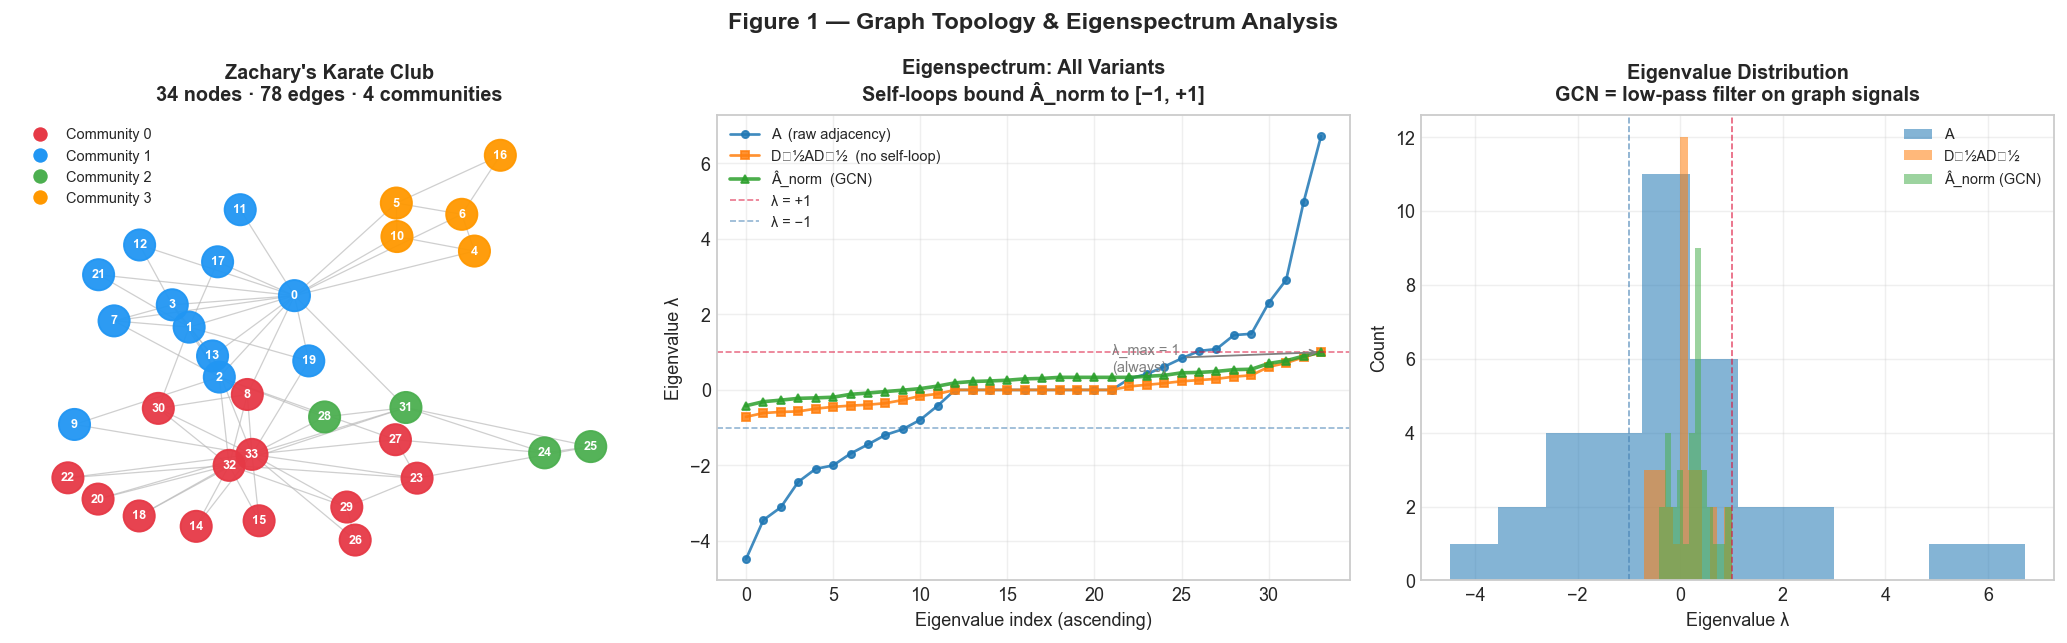

In [12]:
node_colors = [CLASS_COLORS[l] for l in labels]

fig1, axes = plt.subplots(1, 3, figsize=(16, 5))
fig1.suptitle("Figure 1 — Graph Topology & Eigenspectrum Analysis",
              fontsize=13, fontweight="bold")

# — Panel A: Graph —
ax = axes[0]
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#bbbbbb", width=0.7, alpha=0.7)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=300, alpha=0.95)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_color="white", font_weight="bold")
ax.legend(handles=legend_handles, loc="upper left", fontsize=8, framealpha=0.8)
ax.set_title("Zachary's Karate Club\n34 nodes · 78 edges · 4 communities", fontweight="bold")
ax.axis("off")

# — Panel B: Sorted eigenvalues —
ax = axes[1]
idx = np.arange(N)
ax.plot(idx, eigvals_A,    "o-", ms=4, alpha=0.85, label="A  (raw adjacency)")
ax.plot(idx, eigvals_sym,  "s-", ms=4, alpha=0.85, label="D⁻½AD⁻½  (no self-loop)")
ax.plot(idx, eigvals_norm, "^-", ms=4, alpha=0.85, lw=2, label="Â_norm  (GCN)")
ax.axhline(+1.0, color="crimson",   ls="--", lw=0.9, alpha=0.6, label="λ = +1")
ax.axhline(-1.0, color="steelblue", ls="--", lw=0.9, alpha=0.6, label="λ = −1")
ax.annotate("λ_max = 1\n(always)", xy=(N-1, eigvals_norm[-1]), xytext=(N-13, 0.5),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=8, color="gray")
ax.set_xlabel("Eigenvalue index (ascending)")
ax.set_ylabel("Eigenvalue λ")
ax.set_title("Eigenspectrum: All Variants\nSelf-loops bound Â_norm to [−1, +1]", fontweight="bold")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# — Panel C: Histogram —
ax = axes[2]
ax.hist(eigvals_A,    bins=12, alpha=0.55, label="A")
ax.hist(eigvals_sym,  bins=12, alpha=0.55, label="D⁻½AD⁻½")
ax.hist(eigvals_norm, bins=12, alpha=0.55, label="Â_norm (GCN)", color="#4CAF50")
ax.axvline(+1.0, color="crimson",   ls="--", lw=0.9, alpha=0.7)
ax.axvline(-1.0, color="steelblue", ls="--", lw=0.9, alpha=0.7)
ax.set_xlabel("Eigenvalue λ"); ax.set_ylabel("Count")
ax.set_title("Eigenvalue Distribution\nGCN = low-pass filter on graph signals", fontweight="bold")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig1_graph_eigenspectrum.png", dpi=150, bbox_inches="tight")
plt.show()


## Figure 2 — Weight Distribution Evolution (KDE)

**What to look for:**
- **Epoch 0:** tight Gaussian near 0 (init `* 0.1`)
- **Later epochs:** distribution spreads/shifts — neurons claiming weight magnitude
- **Bimodality** (if it appears) → neurons specialising into positive vs. negative roles
- **W3** shifts most dramatically — it receives direct class-label gradient

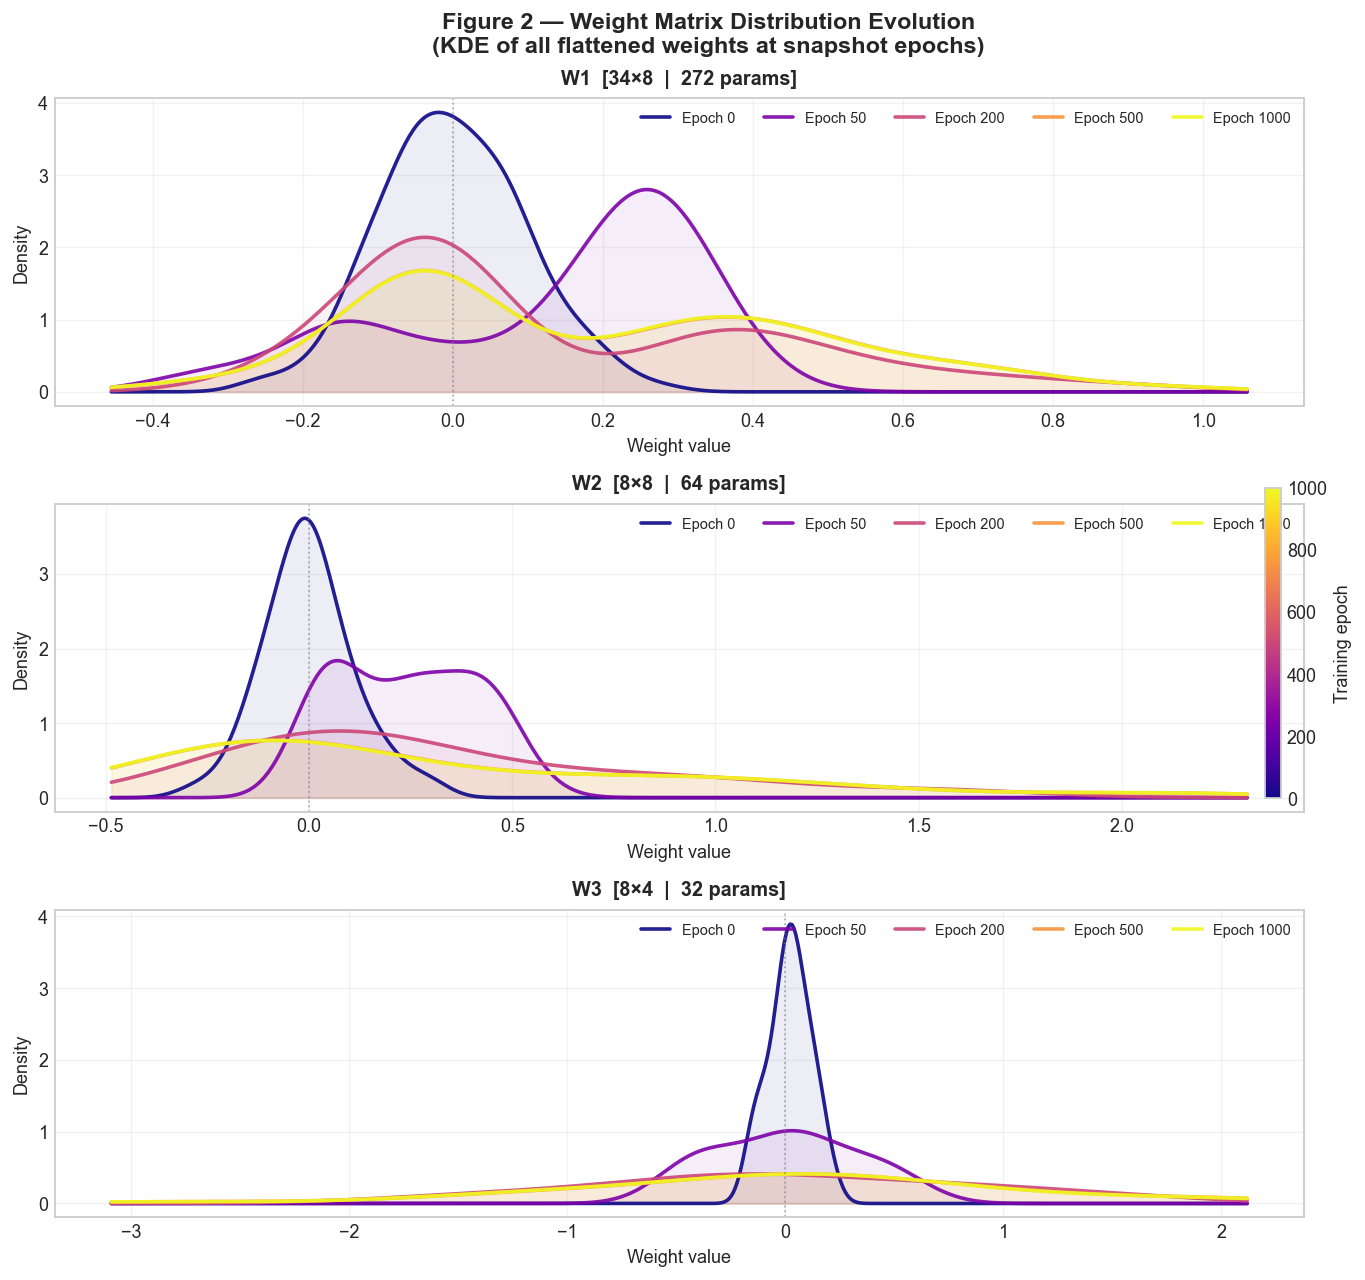

In [ ]:
W_SHAPES = {"W1": f"{IN_DIM}x{HIDDEN}", "W2": f"{HIDDEN}x{HIDDEN}", "W3": f"{HIDDEN}x{OUT_DIM}"}

fig2, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=False)
fig2.suptitle("Figure 2 — Weight Matrix Distribution Evolution\n"
              "(KDE of all flattened weights at snapshot epochs)",
              fontsize=13, fontweight="bold")

n_snaps      = len(SNAPSHOT_AT)
epoch_colors = [EPOCH_CMAP(i / (n_snaps - 1)) for i in range(n_snaps)]

for row_i, wname in enumerate(["W1", "W2", "W3"]):
    ax       = axes[row_i]
    all_vals = np.concatenate([w_snaps[e][wname] for e in SNAPSHOT_AT])
    x_lo     = all_vals.min() - 0.05 * abs(all_vals.min())
    x_hi     = all_vals.max() + 0.05 * abs(all_vals.max())
    x_range  = np.linspace(x_lo, x_hi, 600)

    for i, epoch in enumerate(SNAPSHOT_AT):
        vals = w_snaps[epoch][wname]
        if vals.std() < 1e-7: continue
        kde = gaussian_kde(vals, bw_method="silverman")
        y   = kde(x_range)
        ax.plot(x_range, y, color=epoch_colors[i], lw=2, label=f"Epoch {epoch}", alpha=0.9)
        ax.fill_between(x_range, y, alpha=0.07, color=epoch_colors[i])

    ax.axvline(0, color="gray", ls=":", lw=1, alpha=0.6)
    n_params = getattr(model, wname).numel()
    ax.set_title(f"{wname}  [{W_SHAPES[wname]}  |  {n_params} params]", fontweight="bold")
    ax.set_xlabel("Weight value"); ax.set_ylabel("Density")
    ax.legend(loc="upper right", fontsize=8, ncol=n_snaps)
    ax.grid(alpha=0.25)

sm = plt.cm.ScalarMappable(cmap=EPOCH_CMAP, norm=plt.Normalize(vmin=0, vmax=EPOCHS))
sm.set_array([])
cbar = fig2.colorbar(sm, ax=axes, orientation="vertical", fraction=0.014, pad=0.02)
cbar.set_label("Training epoch", fontsize=10)

plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.savefig("fig2_weight_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## Figure 3 — Layer-wise Node Embeddings (PCA)

Each panel shows **PCA of Hˡ** from the final trained model. Panels share independent axes.  
Graph edges are drawn lightly in embedding space to show neighbourhood structure.  
**DE** (Dirichlet energy) printed per panel — watch it decrease with depth.

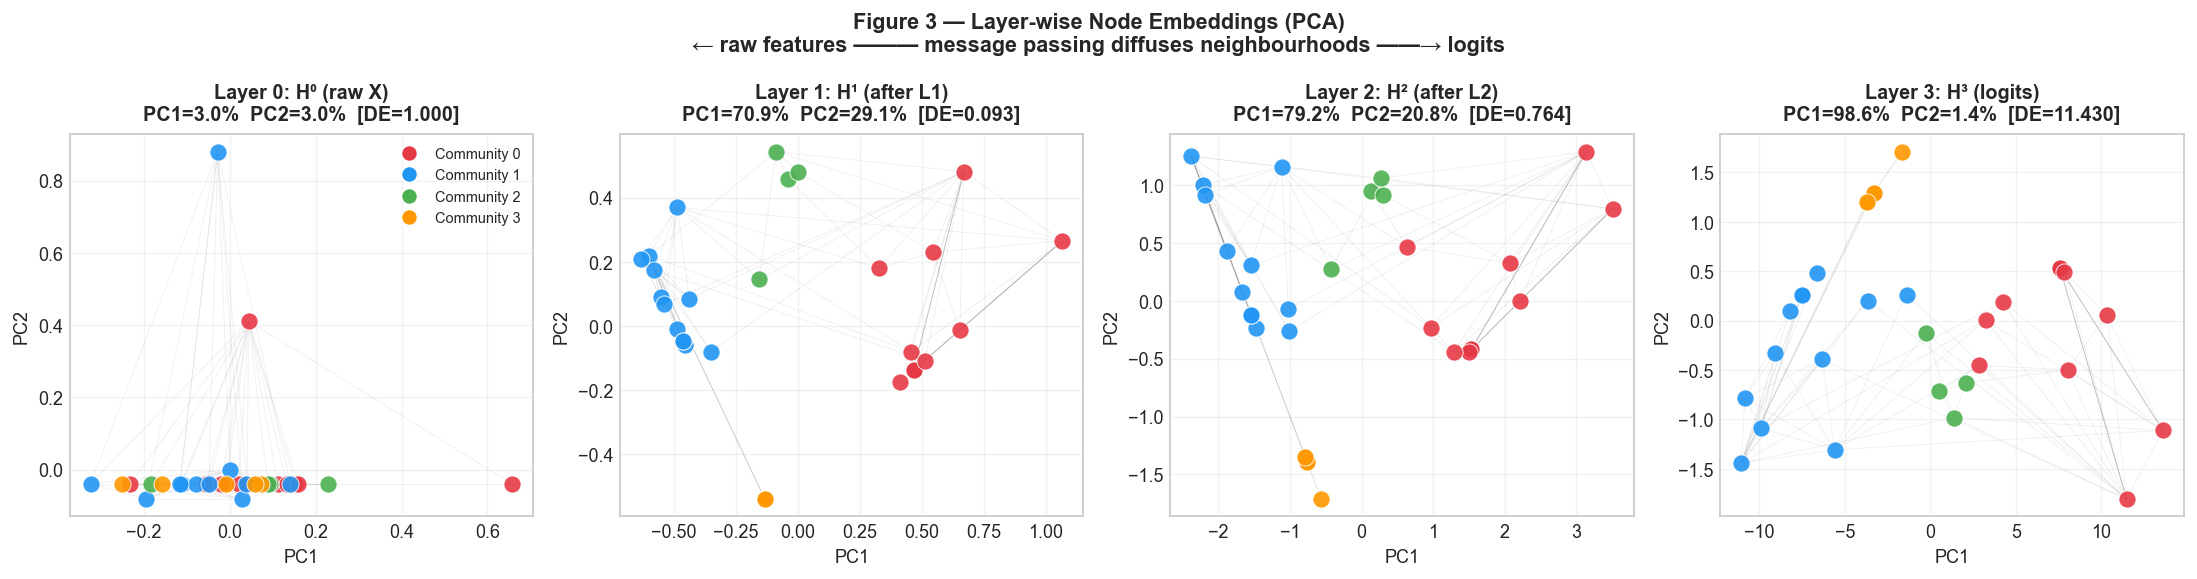

In [14]:
fig3, axes = plt.subplots(1, 4, figsize=(17, 4.5))
fig3.suptitle("Figure 3 — Layer-wise Node Embeddings (PCA)\n"
              "← raw features ——— message passing diffuses neighbourhoods ——→ logits",
              fontsize=12, fontweight="bold")

for i, (H, name) in enumerate(zip(all_layers, LAYER_NAMES)):
    ax   = axes[i]
    H_np = H.detach().numpy()
    pca  = PCA(n_components=2)
    H_2d = pca.fit_transform(H_np)
    var  = pca.explained_variance_ratio_

    for u, v in G.edges():
        ax.plot([H_2d[u,0], H_2d[v,0]], [H_2d[u,1], H_2d[v,1]],
                c="gray", alpha=0.12, lw=0.5, zorder=1)
    for cls in range(K):
        mask = labels == cls
        ax.scatter(H_2d[mask,0], H_2d[mask,1], c=CLASS_COLORS[cls],
                   s=90, alpha=0.9, zorder=3, edgecolors="white", linewidths=0.5)

    ax.set_title(f"Layer {i}: {name}\n"
                 f"PC1={var[0]*100:.1f}%  PC2={var[1]*100:.1f}%  "
                 f"[DE={layer_energies[i]:.3f}]", fontweight="bold")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    if i == 0:
        ax.legend(handles=legend_handles, fontsize=8, loc="best", framealpha=0.8)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("fig3_layerwise_pca.png", dpi=150, bbox_inches="tight")
plt.show()


## Figure 4 — Training-time Embedding Evolution (H², shared PCA axes)

All panels use **one globally fitted PCA** (on the union of all snapshots) so motion between panels is geometrically meaningful.  
Each panel annotates both **Dirichlet energy** and **v₁ alignment** — the two oversmoothing diagnostics together.

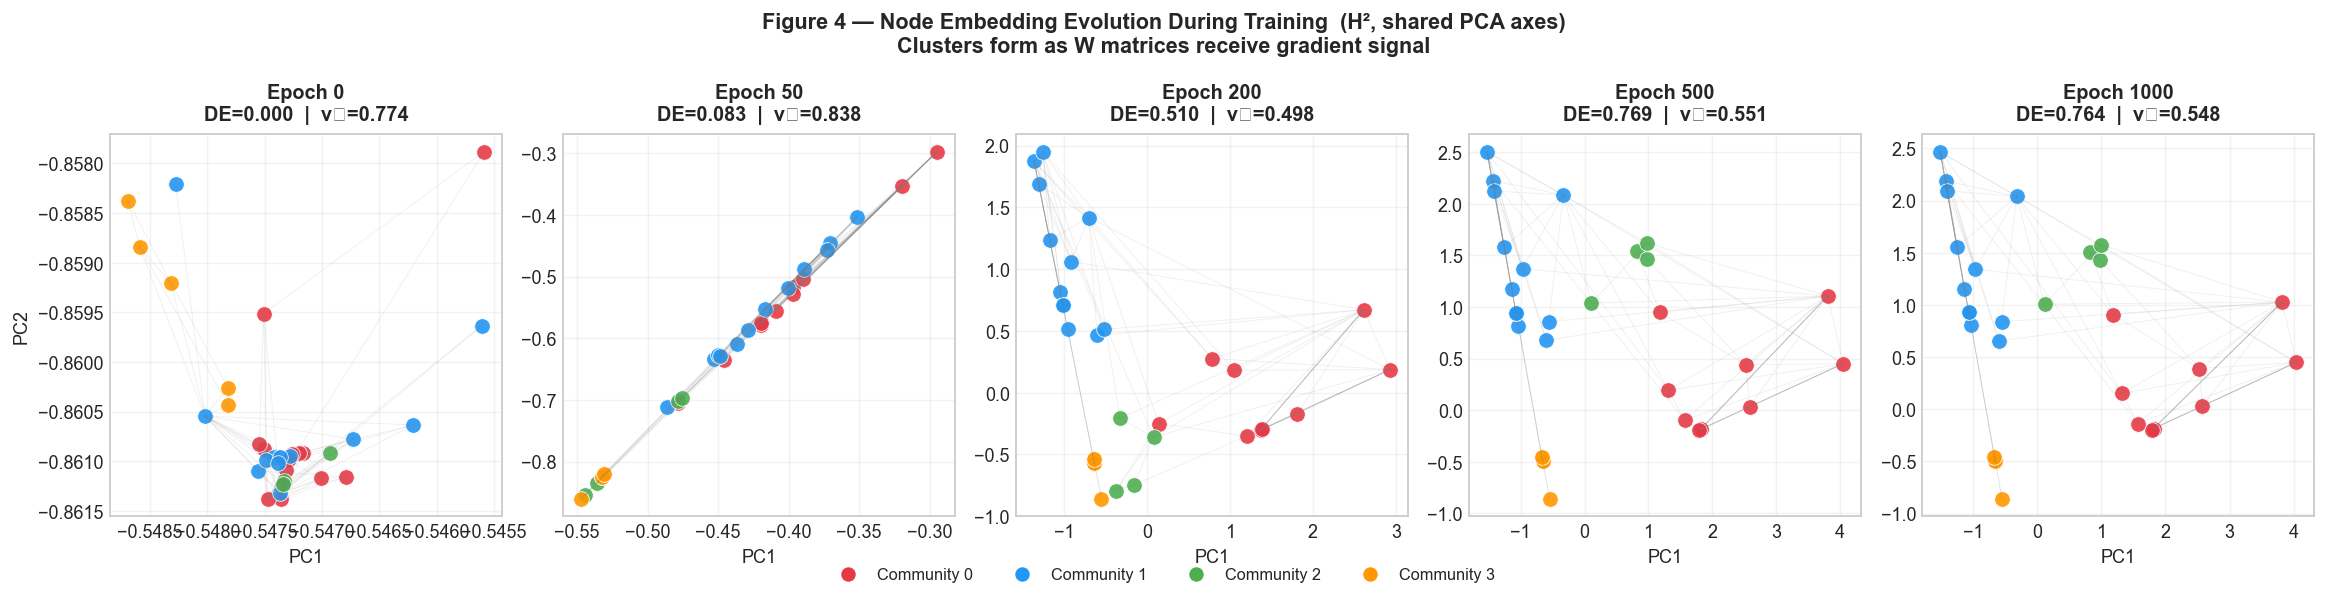

In [15]:
pca_global  = PCA(n_components=2)
pca_global.fit(np.vstack([emb_snaps[e] for e in SNAPSHOT_AT]))

fig4, axes = plt.subplots(1, len(SNAPSHOT_AT), figsize=(18, 4.5))
fig4.suptitle("Figure 4 — Node Embedding Evolution During Training  (H², shared PCA axes)\n"
              "Clusters form as W matrices receive gradient signal",
              fontsize=12, fontweight="bold")

for j, epoch in enumerate(SNAPSHOT_AT):
    ax   = axes[j]
    H_2d = pca_global.transform(emb_snaps[epoch])

    for u, v in G.edges():
        ax.plot([H_2d[u,0], H_2d[v,0]], [H_2d[u,1], H_2d[v,1]],
                c="gray", alpha=0.12, lw=0.5)
    for cls in range(K):
        mask = labels == cls
        ax.scatter(H_2d[mask,0], H_2d[mask,1], c=CLASS_COLORS[cls],
                   s=75, alpha=0.9, edgecolors="white", linewidths=0.5)

    de  = dirichlet_energy(torch.tensor(emb_snaps[epoch]))
    aln = align_to_v1(emb_snaps[epoch])
    ax.set_title(f"Epoch {epoch}\nDE={de:.3f}  |  v₁={aln:.3f}", fontweight="bold")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2" if j == 0 else "")
    ax.grid(alpha=0.25)

fig4.legend(handles=legend_handles, loc="lower center",
            ncol=K, fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig("fig4_embedding_evolution.png", dpi=150, bbox_inches="tight")
plt.show()


## Figure 5 — Dirichlet Energy & Oversmoothing

Three complementary views of the same phenomenon:

| Panel | What it shows |
|-------|--------------|
| **Left** | Layer depth → energy decreases even in a trained model |
| **Middle** | Training may temporarily raise energy (representations separate), then stabilise |
| **Right** | Pure diffusion decays exponentially — the spectral baseline for oversmoothing |

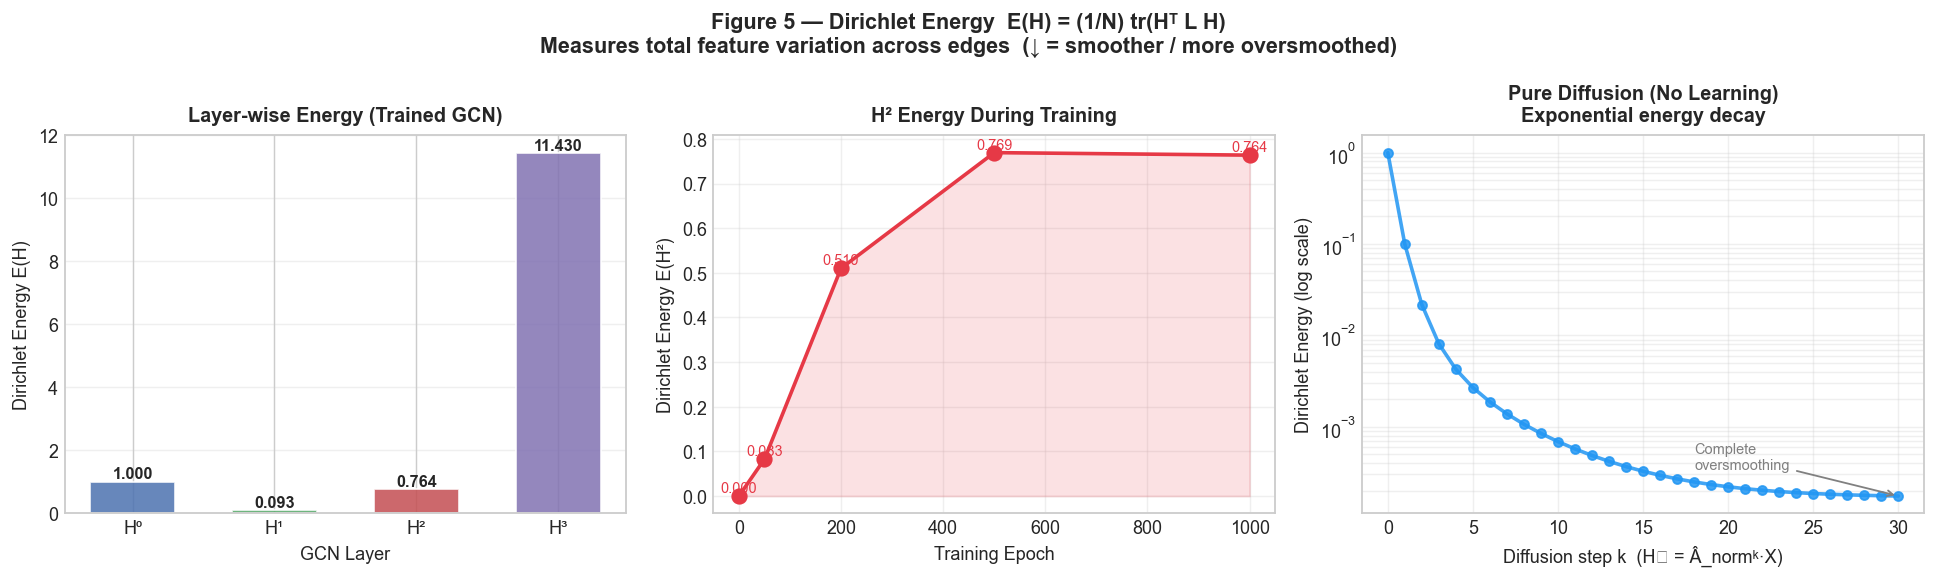

In [16]:
BAR_COLORS = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

fig5, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig5.suptitle("Figure 5 — Dirichlet Energy  E(H) = (1/N) tr(Hᵀ L H)\n"
              "Measures total feature variation across edges  (↓ = smoother / more oversmoothed)",
              fontsize=12, fontweight="bold")

# — Panel A: layer-wise —
ax = axes[0]
bars = ax.bar(LAYER_SHORT, layer_energies, color=BAR_COLORS, alpha=0.85, edgecolor="white", width=0.6)
for bar, v in zip(bars, layer_energies):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xlabel("GCN Layer"); ax.set_ylabel("Dirichlet Energy E(H)")
ax.set_title("Layer-wise Energy (Trained GCN)", fontweight="bold")
ax.grid(alpha=0.3, axis="y")

# — Panel B: epoch-wise —
ax = axes[1]
ax.plot(SNAPSHOT_AT, epoch_energies, "o-", color="#E63946", lw=2, ms=8, zorder=3)
ax.fill_between(SNAPSHOT_AT, epoch_energies, alpha=0.15, color="#E63946")
for ep, en in zip(SNAPSHOT_AT, epoch_energies):
    ax.text(ep, en + 0.002, f"{en:.3f}", ha="center", va="bottom", fontsize=8, color="#E63946")
ax.set_xlabel("Training Epoch"); ax.set_ylabel("Dirichlet Energy E(H²)")
ax.set_title("H² Energy During Training", fontweight="bold")
ax.grid(alpha=0.3)

# — Panel C: pure diffusion (log scale) —
ax = axes[2]
steps = np.arange(N_DIFF_STEPS + 1)
ax.semilogy(steps, diff_energies, "o-", color="#2196F3", lw=2, ms=5, alpha=0.85)
ax.set_xlabel("Diffusion step k  (Hₖ = Â_normᵏ·X)")
ax.set_ylabel("Dirichlet Energy (log scale)")
ax.set_title("Pure Diffusion (No Learning)\nExponential energy decay", fontweight="bold")
ax.annotate("Complete\noversmoothing", xy=(N_DIFF_STEPS, diff_energies[-1]),
            xytext=(18, diff_energies[4]*0.08),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=8, color="gray")
ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("fig5_dirichlet_energy.png", dpi=150, bbox_inches="tight")
plt.show()


## Figure 6 — Principal Eigenvector Alignment

**Theory:**  $\hat{A}_{\text{norm}} = U \Lambda U^\top$, with $\lambda_1 = 1$ (unique).  
Applying $\hat{A}_{\text{norm}}^k$:

$$H^{(k)} = U \Lambda^k U^\top X \;\xrightarrow{k \to \infty}\; v_1 (v_1^\top X)$$

All feature channels collapse to scalar multiples of $v_1$ — **oversmoothing in spectral terms**.  
The trained GCN's weight matrices $W$ can partially resist this collapse; the right panel shows it is inevitable without them.

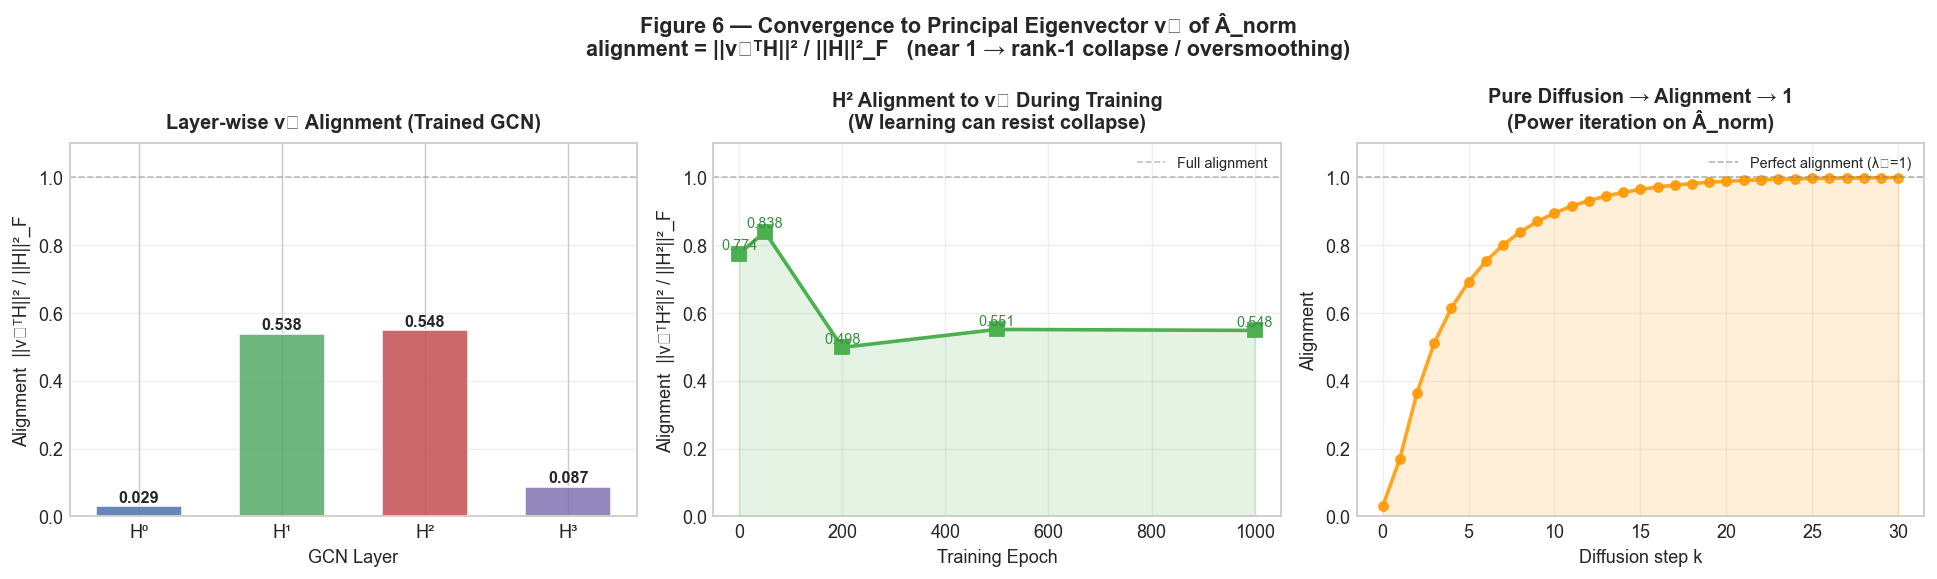

In [17]:
fig6, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig6.suptitle(
    "Figure 6 — Convergence to Principal Eigenvector v₁ of Â_norm\n"
    "alignment = ||v₁ᵀH||² / ||H||²_F   (near 1 → rank-1 collapse / oversmoothing)",
    fontsize=12, fontweight="bold")

# — Panel A: layer-wise —
ax = axes[0]
bars = ax.bar(LAYER_SHORT, layer_alignments, color=BAR_COLORS, alpha=0.85, edgecolor="white", width=0.6)
for bar, v in zip(bars, layer_alignments):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylim(0, 1.1); ax.axhline(1.0, color="gray", ls="--", lw=0.9, alpha=0.5)
ax.set_xlabel("GCN Layer"); ax.set_ylabel("Alignment  ||v₁ᵀH||² / ||H||²_F")
ax.set_title("Layer-wise v₁ Alignment (Trained GCN)", fontweight="bold")
ax.grid(alpha=0.3, axis="y")

# — Panel B: epoch-wise —
ax = axes[1]
ax.plot(SNAPSHOT_AT, epoch_alignments, "s-", color="#4CAF50", lw=2, ms=8, zorder=3)
ax.fill_between(SNAPSHOT_AT, epoch_alignments, alpha=0.15, color="#4CAF50")
ax.axhline(1.0, color="gray", ls="--", lw=0.9, alpha=0.5, label="Full alignment")
for ep, al in zip(SNAPSHOT_AT, epoch_alignments):
    ax.text(ep, al + 0.005, f"{al:.3f}", ha="center", va="bottom", fontsize=8, color="#388E3C")
ax.set_ylim(0, 1.1); ax.set_xlabel("Training Epoch")
ax.set_ylabel("Alignment  ||v₁ᵀH²||² / ||H²||²_F")
ax.set_title("H² Alignment to v₁ During Training\n(W learning can resist collapse)", fontweight="bold")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# — Panel C: pure diffusion —
steps = np.arange(N_DIFF_STEPS + 1)
ax = axes[2]
ax.plot(steps, diff_alignments, "o-", color="#FF9800", lw=2, ms=5, alpha=0.85)
ax.axhline(1.0, color="gray", ls="--", lw=0.9, alpha=0.6, label="Perfect alignment (λ₁=1)")
ax.fill_between(steps, diff_alignments, alpha=0.15, color="#FF9800")
ax.set_ylim(0, 1.1); ax.set_xlabel("Diffusion step k")
ax.set_ylabel("Alignment"); ax.legend(fontsize=8)
ax.set_title("Pure Diffusion → Alignment → 1\n(Power iteration on Â_norm)", fontweight="bold")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig6_eigenvector_alignment.png", dpi=150, bbox_inches="tight")
plt.show()


## Figure 7 — Pure Diffusion Snapshots

The most direct visual proof of oversmoothing.  
Nodes start as **perfectly separated one-hot vectors** (34 unique directions in 34-D space).  
After just ~15 applications of $\hat{A}_{\text{norm}}$ — **with no learned weights at all** — every node collapses to essentially the same point in PCA space.  
This is the baseline any GCN design must fight against.

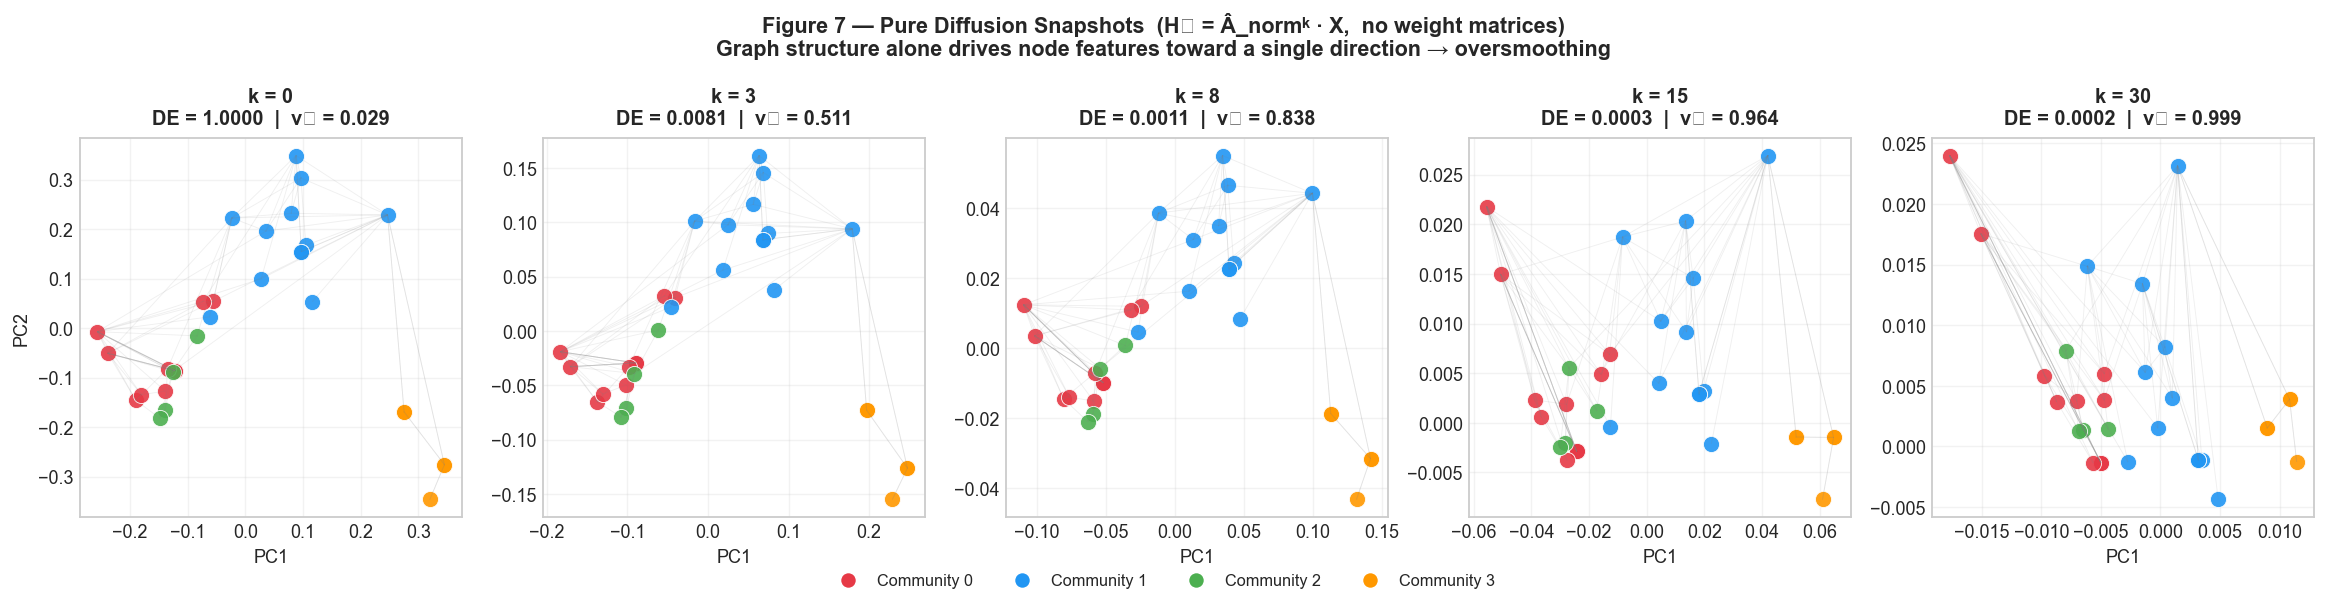

In [18]:
pca_diff = PCA(n_components=2)
pca_diff.fit(np.vstack([diff_emb_snaps[s] for s in DIFF_SHOW_STEPS]))

fig7, axes = plt.subplots(1, len(DIFF_SHOW_STEPS), figsize=(18, 4.5))
fig7.suptitle(
    "Figure 7 — Pure Diffusion Snapshots  (Hₖ = Â_normᵏ · X,  no weight matrices)\n"
    "Graph structure alone drives node features toward a single direction → oversmoothing",
    fontsize=12, fontweight="bold")

for j, step in enumerate(DIFF_SHOW_STEPS):
    ax   = axes[j]
    H_2d = pca_diff.transform(diff_emb_snaps[step])

    for u, v in G.edges():
        ax.plot([H_2d[u,0], H_2d[v,0]], [H_2d[u,1], H_2d[v,1]],
                c="gray", alpha=0.12, lw=0.5)
    for cls in range(K):
        mask = labels == cls
        ax.scatter(H_2d[mask,0], H_2d[mask,1], c=CLASS_COLORS[cls],
                   s=80, alpha=0.9, edgecolors="white", linewidths=0.5)

    ax.set_title(f"k = {step}\nDE = {diff_energies[step]:.4f}  |  v₁ = {diff_alignments[step]:.3f}",
                 fontweight="bold")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2" if j == 0 else "")
    ax.grid(alpha=0.25)

fig7.legend(handles=legend_handles, loc="lower center",
            ncol=K, fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.savefig("fig7_diffusion_snapshots.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

In [19]:
print("=" * 62)
print("  RESULTS SUMMARY")
print("=" * 62)
print(f"  Dataset          : Karate Club  (N={N}, K={K})")
print(f"  Model            : 3-layer GCN  [{IN_DIM}→{HIDDEN}→{HIDDEN}→{OUT_DIM}]")
print(f"  Training epochs  : {EPOCHS}   |   Final loss: {losses[-1]:.4f}")
print()
print("  Eigenvalue ranges:")
print(f"    A           : [{eigvals_A.min():.4f},  {eigvals_A.max():.4f}]")
print(f"    D⁻½AD⁻½    : [{eigvals_sym.min():.4f},  {eigvals_sym.max():.4f}]")
print(f"    Â_norm(GCN) : [{eigvals_norm.min():.4f},  {eigvals_norm.max():.4f}]")
print()
print("  Layer  |  Dirichlet Energy  |  v₁ Alignment")
print("  " + "-"*44)
for name, e, a in zip(LAYER_SHORT, layer_energies, layer_alignments):
    print(f"  {name}    |  {e:.4f}              |  {a:.4f}")
print()
print("  Pure diffusion (k=0 → k=30):")
print(f"    Energy    : {diff_energies[0]:.4f}  →  {diff_energies[-1]:.2e}")
print(f"    v₁ align  : {diff_alignments[0]:.4f}  →  {diff_alignments[-1]:.4f}")
print("=" * 62)


  RESULTS SUMMARY
  Dataset          : Karate Club  (N=34, K=4)
  Model            : 3-layer GCN  [34→8→8→4]
  Training epochs  : 1000   |   Final loss: 0.3537

  Eigenvalue ranges:
    A           : [-4.4872,  6.7257]
    D⁻½AD⁻½    : [-0.7146,  1.0000]
    Â_norm(GCN) : [-0.4201,  1.0000]

  Layer  |  Dirichlet Energy  |  v₁ Alignment
  --------------------------------------------
  H⁰    |  1.0000              |  0.0294
  H¹    |  0.0928              |  0.5384
  H²    |  0.7636              |  0.5481
  H³    |  11.4296              |  0.0869

  Pure diffusion (k=0 → k=30):
    Energy    : 1.0000  →  1.74e-04
    v₁ align  : 0.0294  →  0.9986
